#📌 Extracción

In [1]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [2]:
df = df[df["Churn"].notna() & (df["Churn"].str.strip() != "")]
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [3]:
len(df['customerID'])

7043

In [4]:
# df["account.Charges.Total"] = (
#     df["account.Charges.Total"]
#     .astype(str)        # asegurar texto
#     .str.strip()        # quitar espacios
#     .replace("", "0")   # vacío → "0"
#     .astype(float)      # convertir a float
# )

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [6]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [7]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
(df.isna() | df.astype(str).applymap(lambda x: x.strip() == "")).sum()

/tmp/ipykernel_322/1309006456.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  (df.isna() | df.astype(str).applymap(lambda x: x.strip() == "")).sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
display(pd.unique(df["customerID"]))
len(pd.unique(df["customerID"]))

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], dtype=object)

7043

In [10]:
display(pd.unique(df["Churn"]))
len(pd.unique(df["Churn"]))

array(['No', 'Yes'], dtype=object)

2

In [11]:
display(pd.unique(df["customer.gender"]))
len(pd.unique(df["customer.gender"]))

array(['Female', 'Male'], dtype=object)

2

In [12]:
display(pd.unique(df["customer.Partner"]))
len(pd.unique(df["customer.Partner"]))

array(['Yes', 'No'], dtype=object)

2

In [13]:
display(pd.unique(df["customer.SeniorCitizen"]))
len(pd.unique(df["customer.SeniorCitizen"]))

array([0, 1])

2

In [14]:
display(pd.unique(df["customer.Dependents"]))
len(pd.unique(df["customer.Dependents"]))

array(['Yes', 'No'], dtype=object)

2

In [15]:
display(pd.unique(df["customer.tenure"]))
len(pd.unique(df["customer.tenure"]))

array([ 9,  4, 13,  3, 71, 63,  7, 65, 54, 72,  5, 56, 34,  1, 45, 50, 23,
       55, 26, 69, 37, 49, 66, 67, 20, 43, 59, 12, 27,  2, 25, 29, 14, 35,
       64, 39, 40, 11,  6, 30, 70, 57, 58, 16, 32, 33, 10, 21, 61, 15, 44,
       22, 24, 19, 47, 62, 46, 52,  8, 60, 48, 28, 41, 53, 68, 31, 36, 17,
       18, 51, 38, 42,  0])

73

In [16]:
display(pd.unique(df["phone.PhoneService"]))
len(pd.unique(df["phone.PhoneService"]))

array(['Yes', 'No'], dtype=object)

2

In [17]:
display(pd.unique(df["phone.MultipleLines"]))
len(pd.unique(df["phone.MultipleLines"]))

array(['No', 'Yes', 'No phone service'], dtype=object)

3

In [18]:
display(pd.unique(df["internet.InternetService"]))
len(pd.unique(df["internet.InternetService"]))

array(['DSL', 'Fiber optic', 'No'], dtype=object)

3

In [19]:
display(pd.unique(df["internet.OnlineSecurity"]))
len(pd.unique(df["internet.OnlineSecurity"]))

array(['No', 'Yes', 'No internet service'], dtype=object)

3

In [20]:
display(pd.unique(df["internet.OnlineBackup"]))
len(pd.unique(df["internet.OnlineBackup"]))

array(['Yes', 'No', 'No internet service'], dtype=object)

3

In [21]:
display(pd.unique(df["internet.DeviceProtection"]))
len(pd.unique(df["internet.DeviceProtection"]))

array(['No', 'Yes', 'No internet service'], dtype=object)

3

In [22]:
display(pd.unique(df["internet.TechSupport"]))
len(pd.unique(df["internet.TechSupport"]))

array(['Yes', 'No', 'No internet service'], dtype=object)

3

In [23]:
display(pd.unique(df["internet.StreamingTV"]))
len(pd.unique(df["internet.StreamingTV"]))

array(['Yes', 'No', 'No internet service'], dtype=object)

3

In [24]:
display(pd.unique(df["internet.StreamingMovies"]))
len(pd.unique(df["internet.StreamingMovies"]))

array(['No', 'Yes', 'No internet service'], dtype=object)

3

In [25]:
display(pd.unique(df["account.Contract"]))
len(pd.unique(df["account.Contract"]))

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

3

In [26]:
display(pd.unique(df["account.PaperlessBilling"]))
len(pd.unique(df["account.PaperlessBilling"]))

array(['Yes', 'No'], dtype=object)

2

In [27]:
display(pd.unique(df["account.PaymentMethod"]))
len(pd.unique(df["account.PaymentMethod"]))

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

4

In [28]:
display(pd.unique(df["account.Charges.Monthly"]))
len(pd.unique(df["account.Charges.Monthly"]))

array([65.6 , 59.9 , 73.9 , ..., 91.75, 68.8 , 67.85])

1585

In [29]:
display(pd.unique(df["account.Charges.Total"]))
len(pd.unique(df["account.Charges.Total"]))

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

6531

#📊 Carga y análisis

In [30]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**customer.SeniorCitizen**

16.2% de los clientes son adultos mayores.

Eso significa que:

Es un grupo minoritario.

Podría analizarse si el churn es más alto en este segmento.

Puede ser una variable relevante en modelos predictivos.

Insight potencial:

Si los adultos mayores presentan mayor churn, podrían necesitar estrategias de acompañamiento o soporte personalizado.

**customer.tenure (Antigüedad en meses)**

El cliente promedio lleva casi 3 años.

Hay clientes nuevos (0 meses).

El máximo es 72 meses (6 años).

Observación importante:

La mediana (29) es menor que la media (32.37), lo que indica ligera asimetría hacia clientes más antiguos.

Eso significa que el 25% de los clientes tiene menos de 9 meses.

En datasets de telecom, el churn suele concentrarse en los primeros meses.

Insight fuerte aquí:

La antigüedad probablemente será una de las variables más importantes para explicar el churn.

**account.Charges.Monthly**

La mediana es mayor que la media → ligera asimetría negativa.

Hay clientes con planes muy baratos (~18).

Hay clientes premium (~118).

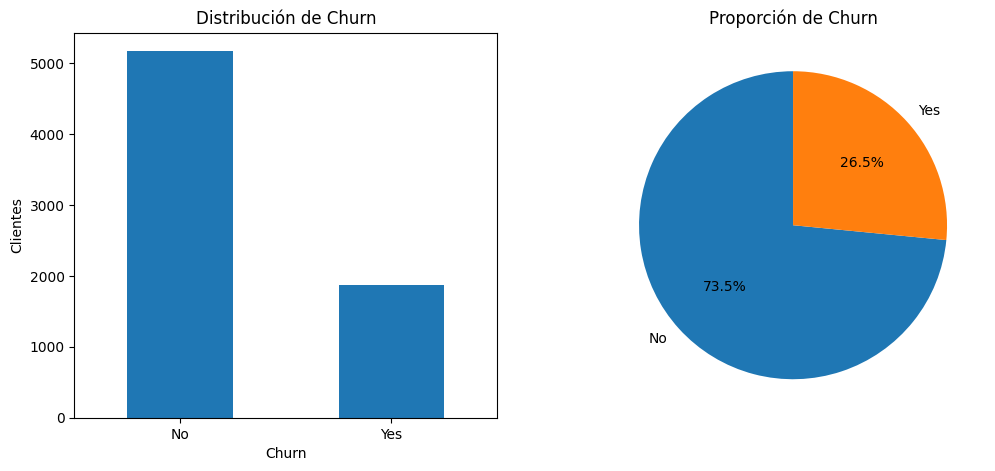

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Barras
df["Churn"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Distribución de Churn")
ax[0].set_xlabel("Churn")
ax[0].set_ylabel("Clientes")
ax[0].tick_params(axis='x', rotation=0)

# Circular
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ax=ax[1]
)
ax[1].set_title("Proporción de Churn")
ax[1].set_ylabel("")

plt.show()

El análisis de la variable Churn revela que el 26,5% de los clientes ha cancelado el servicio, lo que representa una tasa de evasión alta para una empresa de telecomunicaciones. En términos prácticos, significa que más de 1 de cada 4 clientes abandona la compañía, lo cual supone un impacto significativo en los ingresos recurrentes y en la estabilidad del negocio, además de aumentar los costos de adquisición de nuevos usuarios. Este resultado confirma la existencia de un problema relevante de retención y justifica la necesidad de profundizar en los factores que influyen en la cancelación, con el fin de diseñar estrategias efectivas que reduzcan la pérdida de clientes y mejoren la fidelización.

In [32]:
categoricas = [
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.Contract",
    "account.PaperlessBilling",
    "account.PaymentMethod"
]

for var in categoricas:
    print(f"\n===== Churn por {var} =====")

    tabla = pd.crosstab(df[var], df["Churn"], normalize="index") * 100

    display(tabla)


===== Churn por customer.gender =====


Churn,No,Yes
customer.gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



===== Churn por customer.SeniorCitizen =====


Churn,No,Yes
customer.SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261



===== Churn por customer.Partner =====


...

Churn,No,Yes
account.Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



===== Churn por account.PaperlessBilling =====


Churn,No,Yes
account.PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



===== Churn por account.PaymentMethod =====


Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


El análisis de la evasión por variables categóricas evidencia patrones claros y estratégicamente relevantes para la empresa. En primer lugar, el género no muestra diferencias significativas en la tasa de cancelación, por lo que no parece ser un factor determinante. Sin embargo, la variable de adulto mayor revela un comportamiento importante: los clientes mayores presentan una tasa de churn considerablemente más alta que el resto, lo que podría estar relacionado con mayor sensibilidad al precio, dificultades tecnológicas o menor fidelización digital. Asimismo, los clientes sin pareja o sin dependientes muestran niveles de evasión notablemente superiores, lo que sugiere que los vínculos familiares actúan como un factor de estabilidad y arraigo al servicio. En cuanto a los servicios contratados, se observa que el tipo de internet es altamente relevante: los usuarios de fibra óptica presentan una de las tasas de cancelación más elevadas, mientras que quienes no tienen servicio de internet casi no cancelan, lo que podría estar asociado a diferencias en precio o expectativas de calidad. Además, la ausencia de servicios adicionales como seguridad en línea, respaldo, protección de dispositivos o soporte técnico se asocia consistentemente con mayores niveles de churn, indicando que los clientes con mayor integración de servicios tienden a ser más leales. El tipo de contrato es, sin duda, uno de los factores más determinantes: los clientes con contrato mensual presentan una tasa de evasión muy superior a quienes tienen contratos de uno o dos años, lo que demuestra que el compromiso a largo plazo reduce significativamente la probabilidad de cancelación. De igual manera, el método de pago resulta crítico, ya que los clientes que utilizan cheque electrónico muestran la tasa de churn más alta, mientras que los pagos automáticos mediante transferencia bancaria o tarjeta de crédito se asocian con mayor retención. En conjunto, estos hallazgos indican que la evasión está fuertemente influenciada por el nivel de compromiso contractual, el tipo de servicio contratado y el método de pago, lo que sugiere que las estrategias de retención deberían enfocarse en incentivar contratos de mayor duración, promover servicios adicionales, optimizar la experiencia de clientes de fibra óptica y fomentar métodos de pago automáticos para reducir la pérdida de clientes.


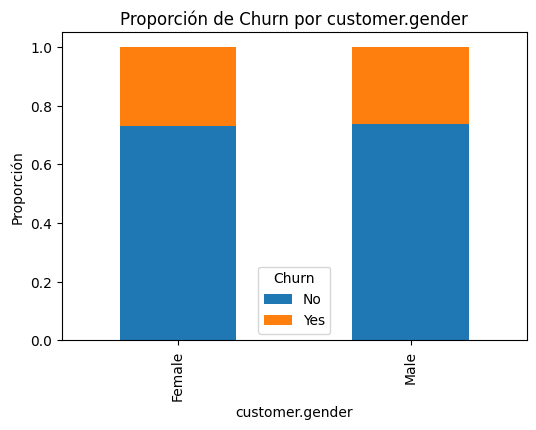

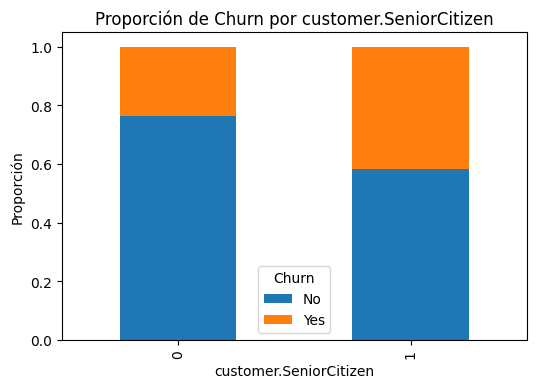

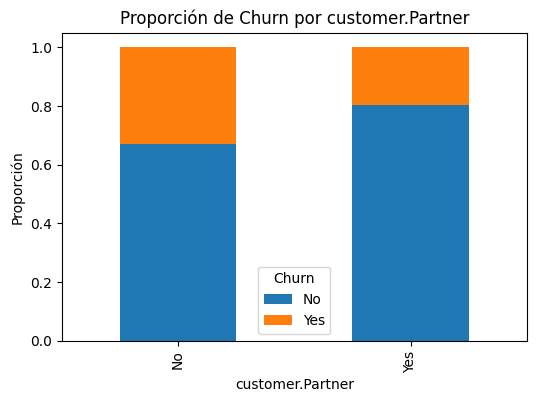

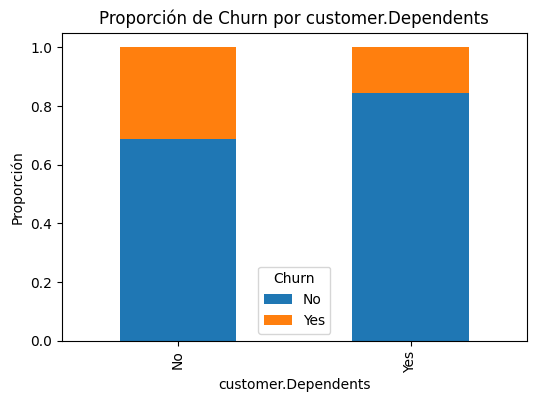

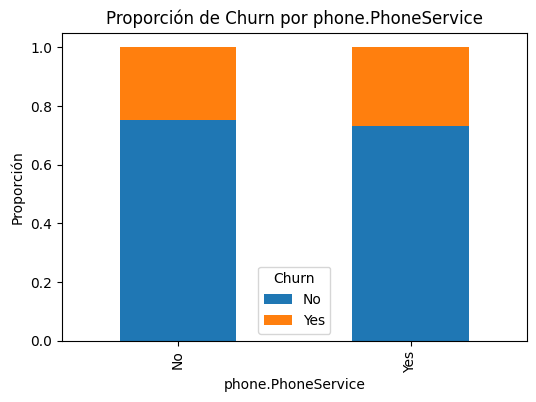

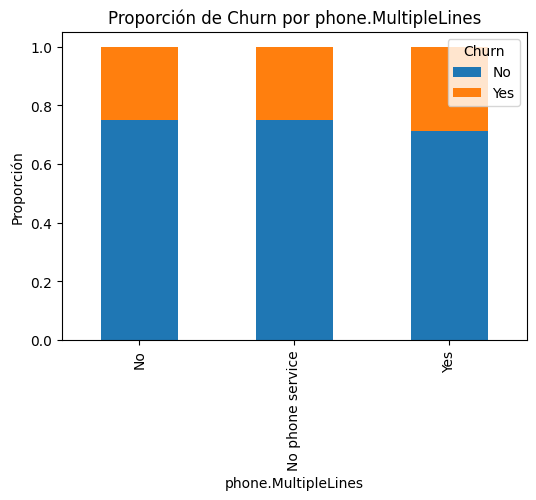

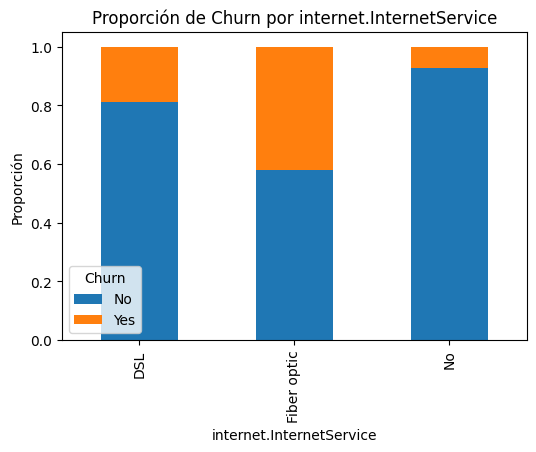

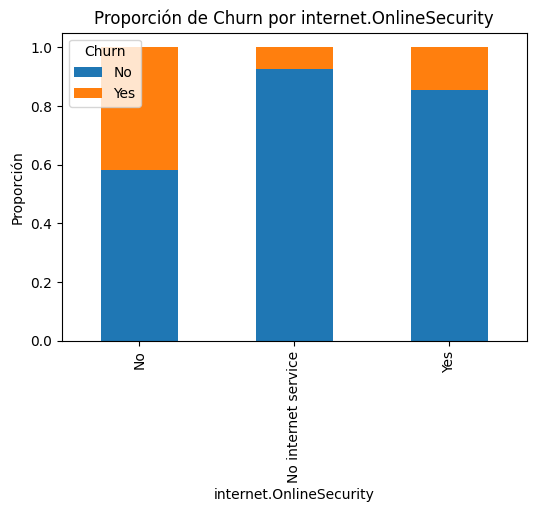

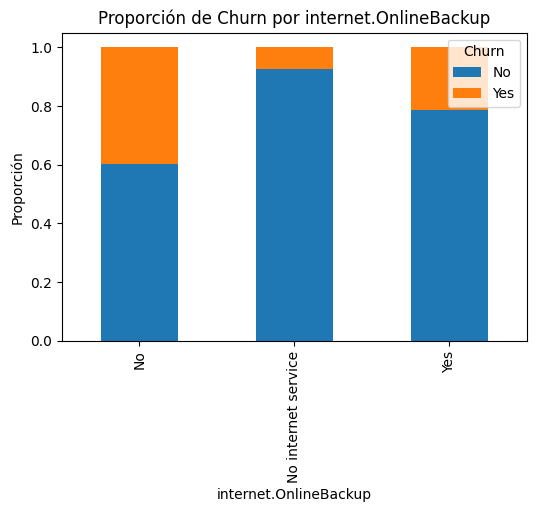

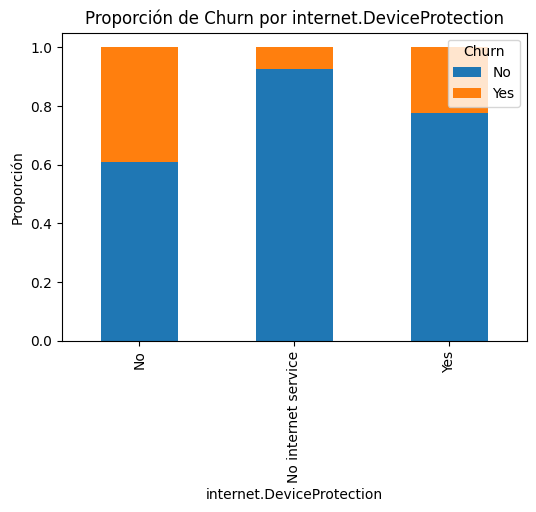

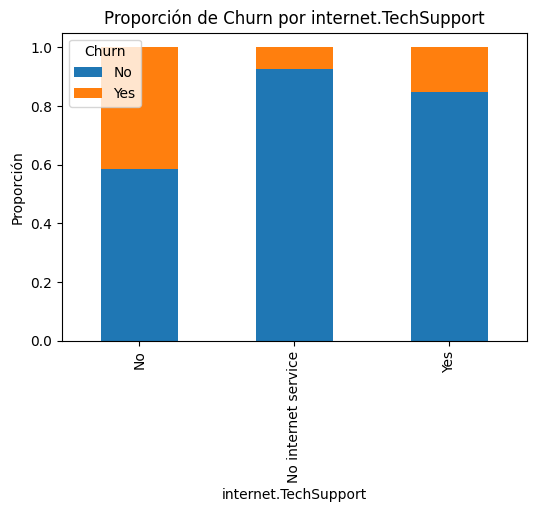

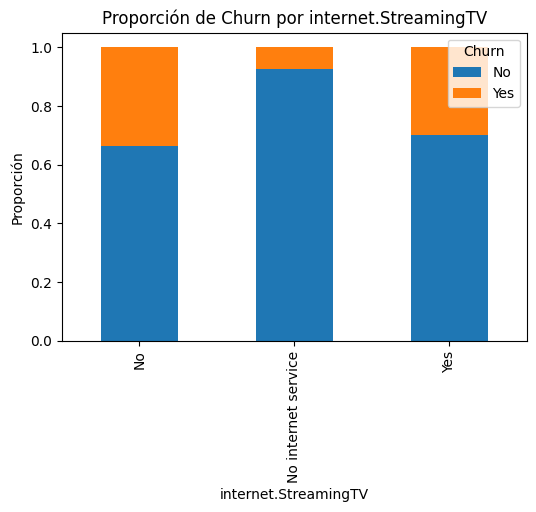

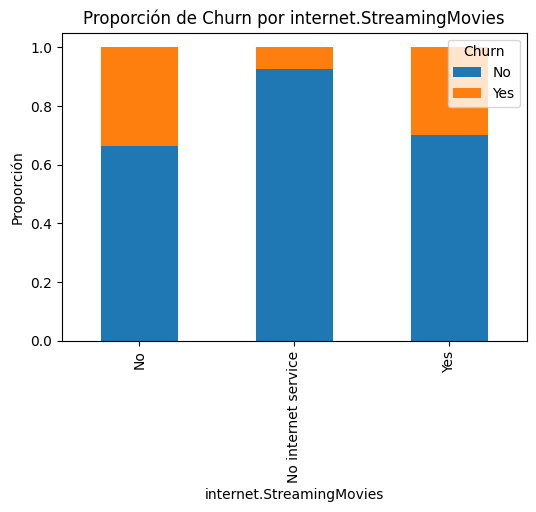

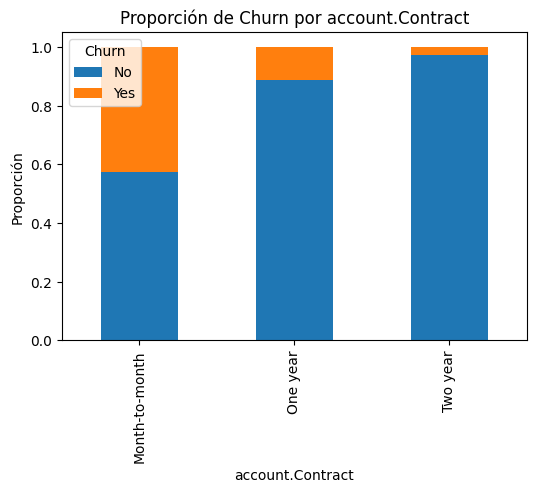

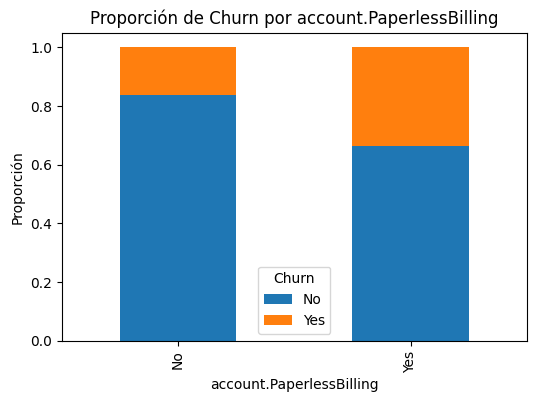

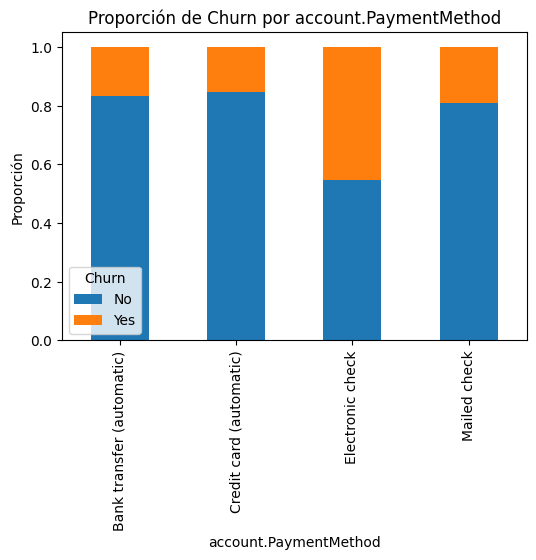

In [33]:
import matplotlib.pyplot as plt

for var in categoricas:
    pd.crosstab(df[var], df["Churn"], normalize="index").plot(
        kind="bar",
        stacked=True,
        figsize=(6,4)
    )

    plt.title(f"Proporción de Churn por {var}")
    plt.ylabel("Proporción")
    plt.xlabel(var)
    plt.legend(title="Churn")
    plt.show()

In [36]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

/tmp/ipykernel_322/1389233792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["account.Charges.Total"] = pd.to_numeric(


In [37]:
numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]

for var in numericas:
    print(f"\n===== {var} =====")

    tabla = df.groupby("Churn")[var].agg(
        ["mean", "median", "std", "min", "max"]
    )

    print(tabla)


===== customer.tenure =====
            mean  median        std  min  max
Churn                                        
No     37.569965    38.0  24.113777    0   72
Yes    17.979133    10.0  19.531123    1   72

===== account.Charges.Monthly =====
            mean  median        std    min     max
Churn                                             
No     61.265124  64.425  31.092648  18.25  118.75
Yes    74.441332  79.650  24.666053  18.85  118.35

===== account.Charges.Total =====
              mean   median          std    min      max
Churn                                                   
No     2555.344141  1683.60  2329.456984  18.80  8672.45
Yes    1531.796094   703.55  1890.822994  18.85  8684.80


El análisis de las variables numéricas evidencia diferencias claras entre los clientes que cancelaron el servicio y aquellos que permanecieron en la compañía. En primer lugar, la antigüedad (customer.tenure) muestra una brecha significativa: los clientes que no cancelaron tienen en promedio 37.6 meses de permanencia, mientras que los que sí cancelaron presentan apenas 18 meses en promedio, con una mediana incluso más baja (10 meses). Esto indica que la evasión ocurre principalmente en etapas tempranas del ciclo de vida del cliente, lo que sugiere que los primeros meses son críticos para la retención. En cuanto a los cargos mensuales (account.Charges.Monthly), los clientes que cancelaron pagan en promedio más (74.44) que aquellos que permanecen (61.27), lo que sugiere que planes más costosos podrían estar asociados con mayor probabilidad de abandono, posiblemente por sensibilidad al precio o percepción de bajo valor. Sin embargo, al analizar el total gastado (account.Charges.Total), se observa que los clientes que no cancelan han acumulado un gasto promedio considerablemente mayor (2555 frente a 1531), lo cual es consistente con su mayor antigüedad. En conjunto, estos hallazgos indican que el churn se concentra principalmente en clientes relativamente nuevos, con cargos mensuales más elevados y menor inversión acumulada en la compañía. Estratégicamente, esto sugiere que Telecom X debería enfocar sus esfuerzos de retención en los primeros meses del contrato, especialmente en clientes con planes de mayor costo, ofreciendo acompañamiento, beneficios adicionales o incentivos que incrementen su percepción de valor y reduzcan la probabilidad de cancelación temprana.

In [34]:
for var in categoricas:
    tabla = pd.crosstab(df[var], df["Churn"], normalize="index") * 100

    if "Yes" in tabla.columns:
        print(f"\n🔎 Mayor churn en {var}:")
        print(tabla["Yes"].sort_values(ascending=False).head())


🔎 Mayor churn en customer.gender:
customer.gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

🔎 Mayor churn en customer.SeniorCitizen:
customer.SeniorCitizen
1    41.681261
0    23.606168
Name: Yes, dtype: float64

🔎 Mayor churn en customer.Partner:
customer.Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

🔎 Mayor churn en customer.Dependents:
customer.Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

🔎 Mayor churn en phone.PhoneService:
phone.PhoneService
Yes    26.709637
No     24.926686
Name: Yes, dtype: float64

🔎 Mayor churn en phone.MultipleLines:
phone.MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Yes, dtype: float64

🔎 Mayor churn en internet.InternetService:
internet.InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

🔎 Mayor churn en internet.OnlineSecurity:
internet.OnlineSecurity
N

El análisis del mayor porcentaje de churn dentro de cada variable categórica permite identificar con mayor claridad los perfiles de mayor riesgo de cancelación. En los servicios relacionados con internet, se observa un patrón consistente: los clientes que no cuentan con servicios adicionales como respaldo en línea, protección de dispositivos o soporte técnico presentan tasas de evasión cercanas al 40% o superiores, mientras que aquellos que sí los contratan reducen significativamente su probabilidad de cancelación. Especialmente relevante es el caso del soporte técnico, donde la diferencia es muy marcada, evidenciando que la falta de acompañamiento aumenta considerablemente el riesgo de abandono. En cuanto al tipo de contrato, los clientes con modalidad mensual (Month-to-month) registran la tasa de churn más alta, superando el 42%, mientras que los contratos de uno y dos años muestran niveles de evasión considerablemente más bajos, confirmando que el compromiso a largo plazo es uno de los principales factores de retención. Asimismo, la facturación electrónica (Paperless Billing) se asocia con mayor tasa de cancelación en comparación con la facturación tradicional, lo que podría estar relacionado con perfiles más digitales y menos fidelizados. Finalmente, el método de pago destaca como un factor crítico: los clientes que utilizan cheque electrónico presentan la tasa de evasión más alta de todas las categorías analizadas (45%), muy por encima de quienes usan pagos automáticos mediante transferencia bancaria o tarjeta de crédito, que muestran niveles de churn significativamente menores. En conjunto, estos resultados refuerzan que el riesgo de cancelación está estrechamente vinculado al nivel de compromiso contractual, la integración de servicios adicionales y el método de pago, proporcionando insumos claros para diseñar estrategias de retención enfocadas en clientes de alto riesgo.

#📄Informe final

🔹 Introducción

El presente análisis tiene como objetivo comprender los factores que influyen en la evasión de clientes (Churn) en Telecom X. La empresa enfrenta una tasa de cancelación del 26.5%, lo que significa que aproximadamente 1 de cada 4 clientes abandona el servicio. Este nivel de pérdida representa un impacto significativo en los ingresos recurrentes, incrementa los costos de adquisición de nuevos clientes y afecta la estabilidad del negocio.

A través de técnicas de análisis exploratorio de datos (EDA), se busca identificar patrones y variables clave asociadas al churn, con el fin de proporcionar información estratégica que permita diseñar acciones efectivas de retención.

🔹 Limpieza y Tratamiento de Datos

El proceso comenzó con la revisión estructural del dataset utilizando funciones como info() y describe(), lo que permitió identificar los tipos de datos y posibles inconsistencias.

Se detectó que la variable account.Charges.Total estaba almacenada como tipo object, debido a la presencia de valores vacíos. Para corregirlo, se realizó una conversión a formato numérico utilizando pd.to_numeric() con manejo de errores, transformando valores inválidos en nulos. Posteriormente, los valores faltantes fueron tratados adecuadamente (asociados a clientes con antigüedad cero), asegurando la coherencia del dataset.

Se verificaron tipos de datos, se validó la ausencia de valores nulos relevantes y se prepararon las variables categóricas y numéricas para el análisis exploratorio.

🔹 Análisis Exploratorio de Datos (EDA)
📌 Distribución General del Churn

El análisis inicial mostró que el 26.5% de los clientes ha cancelado el servicio. Esto confirma un problema relevante de retención que justifica un análisis más profundo de los factores asociados.

📌 Variables Categóricas

El análisis por variables categóricas reveló patrones claros:

Tipo de contrato: Los clientes con contrato mensual presentan una tasa de churn superior al 42%, mientras que los contratos de uno y dos años muestran tasas considerablemente menores (11% y 2.8%, respectivamente). Esta es la variable más determinante.

Método de pago: El uso de cheque electrónico presenta la tasa de evasión más alta (45%), mientras que los pagos automáticos muestran mayor estabilidad.

Servicios adicionales: Los clientes que no cuentan con soporte técnico, respaldo en línea o protección de dispositivos presentan tasas de cancelación cercanas al 40%, mientras que quienes sí los contratan reducen significativamente su churn.

Tipo de internet: Los clientes con fibra óptica muestran una tasa de cancelación elevada (≈42%), mientras que quienes no tienen servicio de internet presentan la tasa más baja.

Factores demográficos: Los adultos mayores presentan mayor evasión que el resto de los clientes. Asimismo, los clientes sin pareja o sin dependientes muestran mayor probabilidad de cancelación.

En contraste, el género no mostró diferencias significativas.

📌 Variables Numéricas

El análisis de variables numéricas mostró diferencias contundentes:

Antigüedad (tenure):
Clientes que permanecen → 37.6 meses en promedio
Clientes que cancelan → 18 meses en promedio

Esto indica que la evasión ocurre principalmente en etapas tempranas del ciclo de vida del cliente.

Cargos mensuales:
Clientes que cancelan pagan en promedio más (74.44) que quienes permanecen (61.27), lo que sugiere posible sensibilidad al precio o menor percepción de valor.

Total gastado:
Los clientes que no cancelan han acumulado mayor gasto total, lo que es consistente con su mayor antigüedad.

En conjunto, los datos muestran que el churn se concentra en clientes relativamente nuevos y con cargos mensuales más elevados.

🔹 Conclusiones e Insights

El análisis evidencia que la evasión no es aleatoria, sino que está fuertemente asociada a:

Bajo compromiso contractual (contratos mensuales).

Métodos de pago no automáticos.

Mayor costo mensual del servicio.

Ausencia de servicios adicionales.

Clientes con menor antigüedad.

Uso de fibra óptica.

La combinación de contrato mensual + altos cargos + falta de servicios adicionales representa el perfil de mayor riesgo.

Por el contrario, los contratos de largo plazo, los pagos automáticos y la integración de múltiples servicios actúan como factores protectores frente al churn.

🔹 Recomendaciones Estratégicas

A partir de los hallazgos, se proponen las siguientes acciones:

Incentivar contratos de largo plazo, ofreciendo descuentos o beneficios exclusivos por migrar de contrato mensual a anual o bianual.

Promover servicios adicionales, especialmente soporte técnico y protección de dispositivos, mediante paquetes o bundles atractivos.

Fomentar métodos de pago automáticos, reduciendo fricciones y aumentando el compromiso financiero.

Fortalecer la experiencia durante los primeros meses, implementando estrategias de onboarding y seguimiento temprano para reducir la cancelación inicial.

Revisar la propuesta de valor del servicio de fibra óptica, evaluando si el precio, calidad o expectativas están influyendo en la alta tasa de churn.

🎯 Cierre

Este análisis exploratorio permitió identificar variables clave asociadas a la evasión de clientes en Telecom X. Los hallazgos proporcionan una base sólida para el desarrollo de modelos predictivos de churn y para la implementación de estrategias de retención basadas en datos.

La información obtenida demuestra cómo el análisis de datos puede transformarse en decisiones estratégicas que impacten directamente la sostenibilidad y rentabilidad del negocio.